#### Eksik Veri Yapısının Görselleştirilmesi

*Gerçek hayat problemlerinde eksik verilerin öncelikli olarak silinmesi veya başka bir değer ile doldurulması yapısal problemlere yol açabilir. Eksik değerler üzerinde işlem yapmadan önce bu eksikliklerin sebepleri araştırılmalı. Yani rassalığı incelenmelidir. Bu inceleme yöntemlerinden biri de eksik veri yapısının görselleştirilmesidir.*

*Veri setimizi ve bu veri setinde yaptığımız işlemleri hatırlayalım:*

In [1]:
import numpy as np
import pandas as pd
V1 = np.array([1,3,6,np.nan,7,1,np.nan,9,15])
V2 = np.array([7,np.nan,5,8,12,np.nan,np.nan,2,3])
V3 = np.array([np.nan,12,5,6,14,7,np.nan,2,31])
df = pd.DataFrame(
    {"V1":V1,
     "V2":V2,
     "V3":V3})
df

,V1,V2,V3
0,1.0,7.0,NaN
1,3.0,NaN,12.0
2,6.0,5.0,5.0
3,NaN,8.0,6.0
4,7.0,12.0,14.0
5,1.0,NaN,7.0
6,NaN,NaN,NaN
7,9.0,2.0,2.0
8,15.0,3.0,31.0


In [2]:
#değişkenlerdeki tam değer sayısı
df.notnull().sum()

V1    7
V2    6
V3    7
dtype: int64

In [3]:
#değişkenlerdeki eksik değer sayısı
df.isnull().sum()

V1    2
V2    3
V3    2
dtype: int64

In [4]:
#veri setindeki toplam eksik değer sayısı
df.isnull().sum().sum()

np.int64(7)

In [5]:
#en az bir eksik değere sahip gözlemler
df[df.isnull().any(axis = 1)]

,V1,V2,V3
0,1.0,7.0,NaN
1,3.0,NaN,12.0
3,NaN,8.0,6.0
5,1.0,NaN,7.0
6,NaN,NaN,NaN


In [6]:
#bütün değerleri eksik olan gözlemlerin getirilmesi
df[df.isnull().all(axis = 1)]

,V1,V2,V3
6,NaN,NaN,NaN


In [7]:
#bütün değerleri dolu olan gözlemler
df[df.notnull().all(axis = 1)]

,V1,V2,V3
2,6.0,5.0,5.0
4,7.0,12.0,14.0
7,9.0,2.0,2.0
8,15.0,3.0,31.0


In [8]:
#eksik veri yapısının görselleştirilmesi

In [9]:
!pip install missingno

In [10]:
import missingno as msno

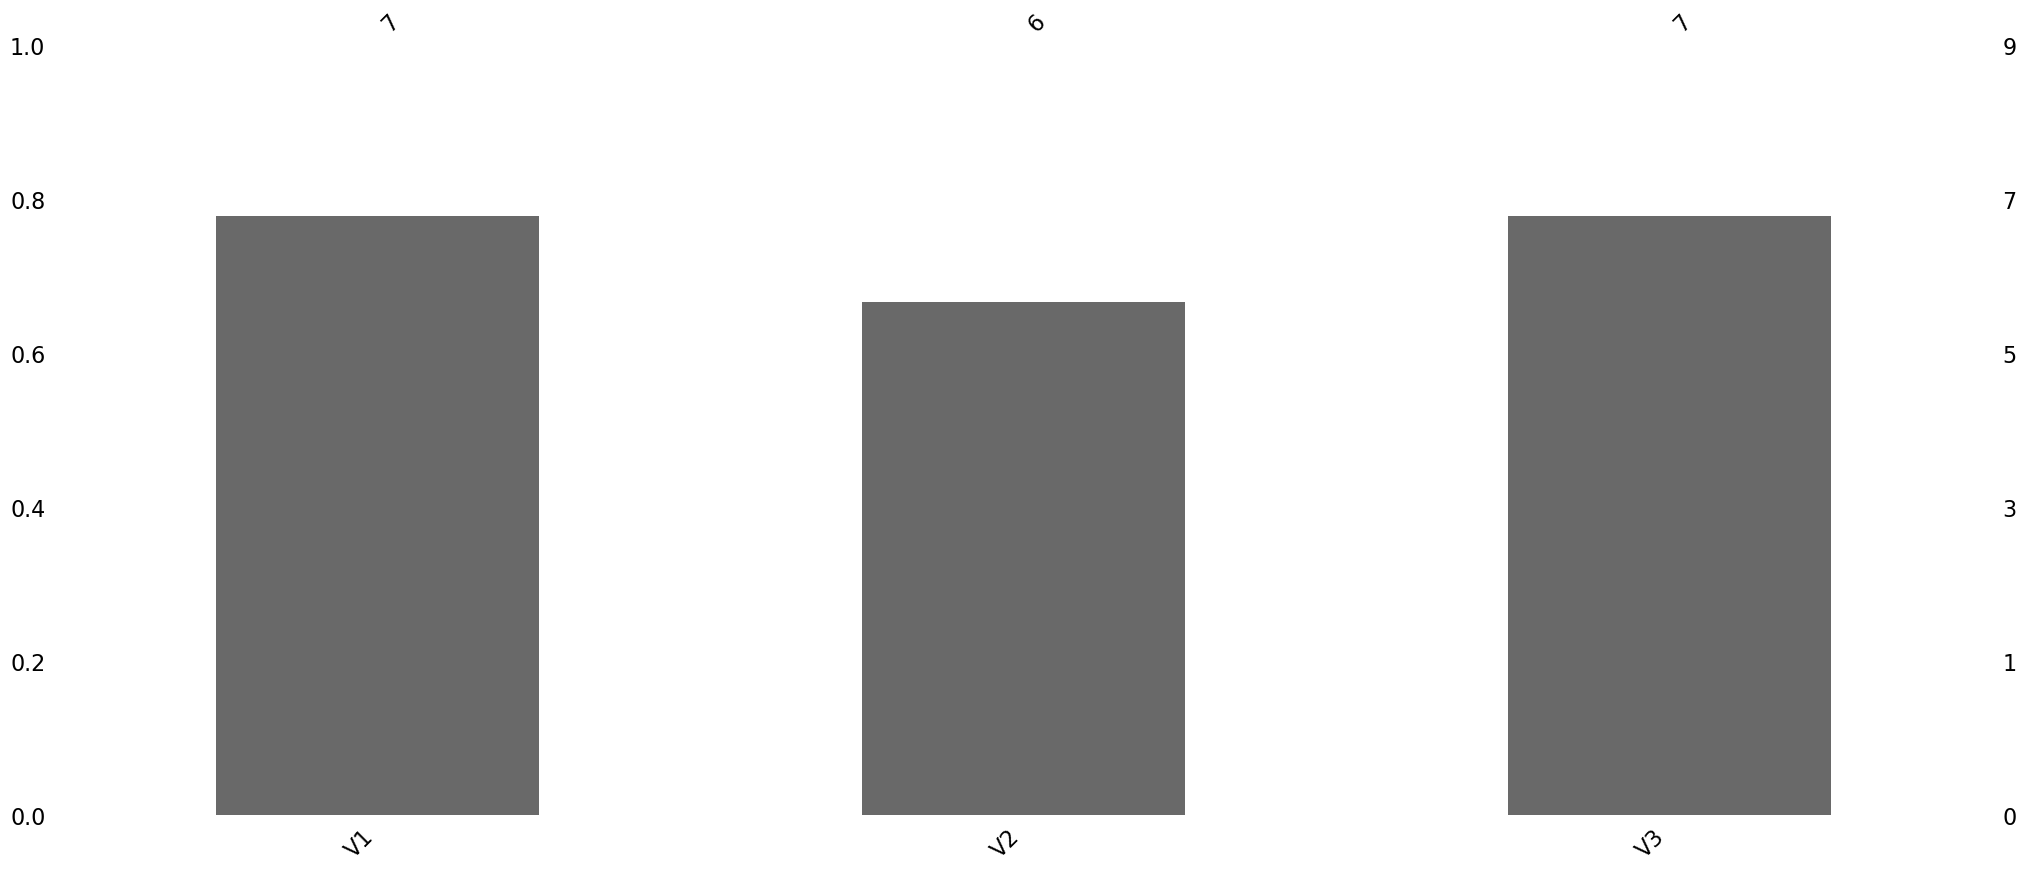

In [11]:
msno.bar(df);

*Sol taraf her bir değişkenin doluluk yüzdesi, üst taraf her bir değişkendeki toplam dolu değer sayısı, sağ taraf değişkendeki toplam gözlem sayısı.*

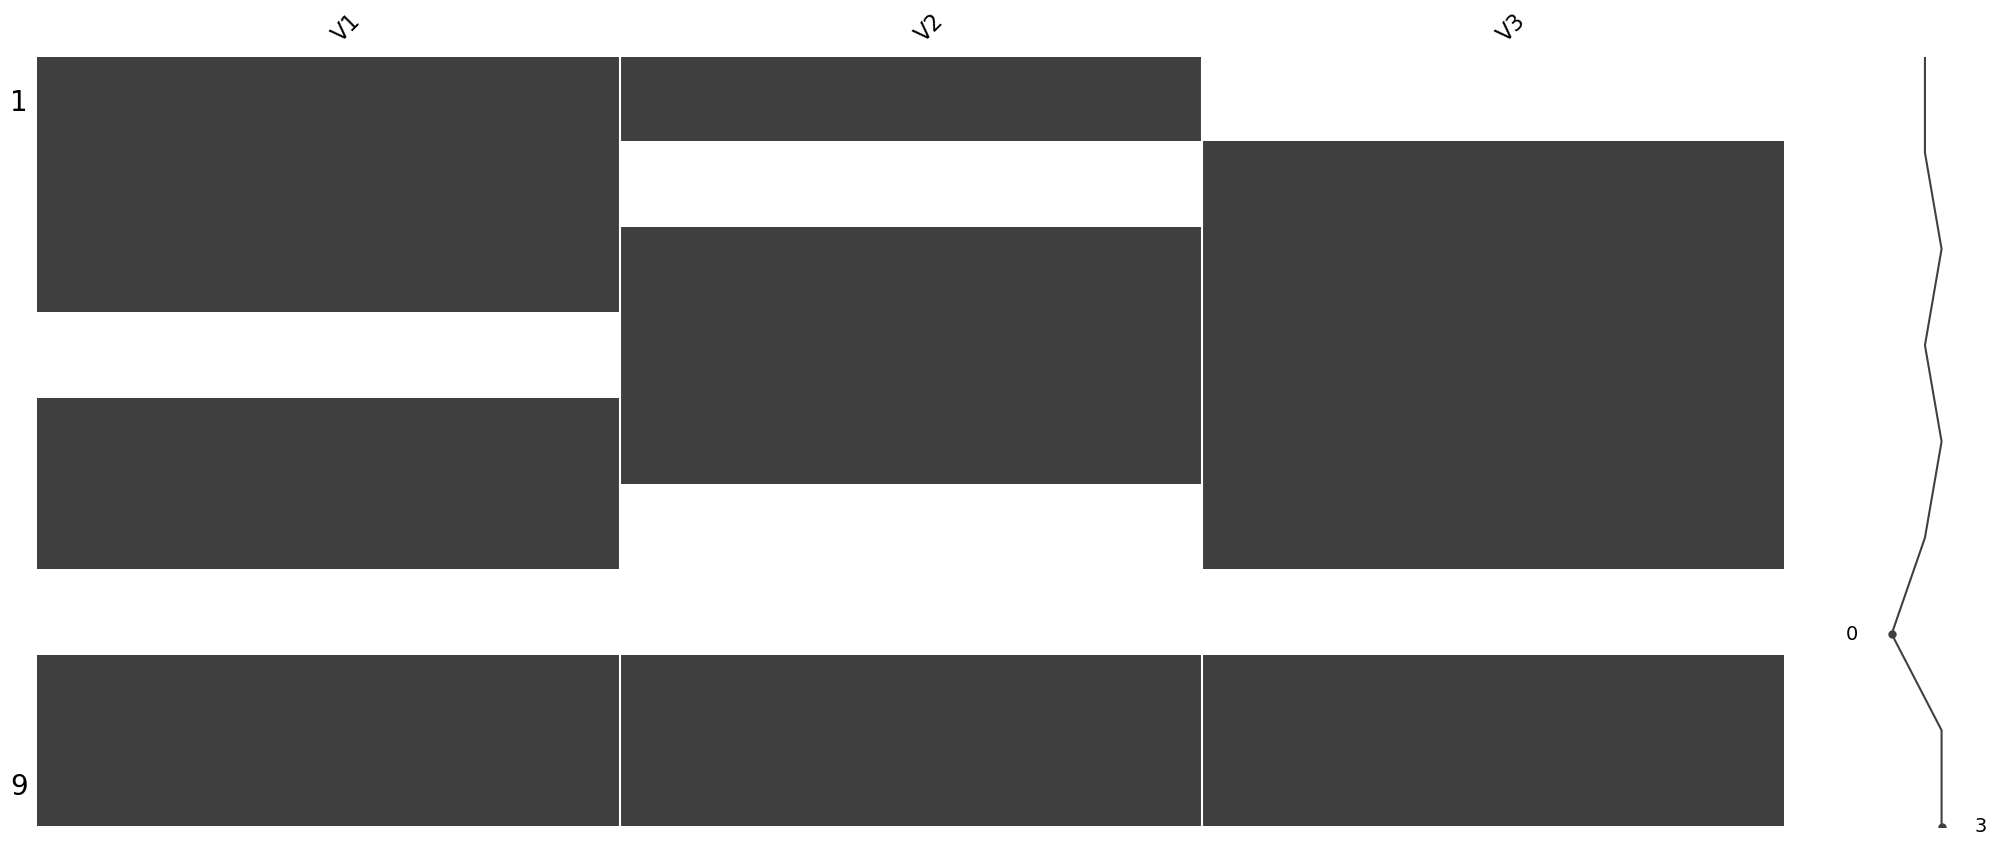

In [12]:
msno.matrix(df);

*Sağ taraftaki kıvrımlı çizgi bütün değerleri dolu olan veya bütün gözlemleri boş olan gözlemler hakkında bilgi veriyor. Sol taraf toplam gözlem sayısını ifade ediyor.*

In [13]:
df

,V1,V2,V3
0,1.0,7.0,NaN
1,3.0,NaN,12.0
2,6.0,5.0,5.0
3,NaN,8.0,6.0
4,7.0,12.0,14.0
5,1.0,NaN,7.0
6,NaN,NaN,NaN
7,9.0,2.0,2.0
8,15.0,3.0,31.0


*Bu veri seti için bu grafikleri okumak kolay. Daha büyük bir veri seti üzerinden incelemelerde bulunalım:*

In [14]:
import seaborn as sns
df = sns.load_dataset('planets')
df.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


In [15]:
df.isnull().sum()

method              0
number              0
orbital_period     43
mass              522
distance          227
year                0
dtype: int64

*Eksik değerlerin doldurulmadan önce rassallığının incelenmesi gerektiğini söylemiştik.*

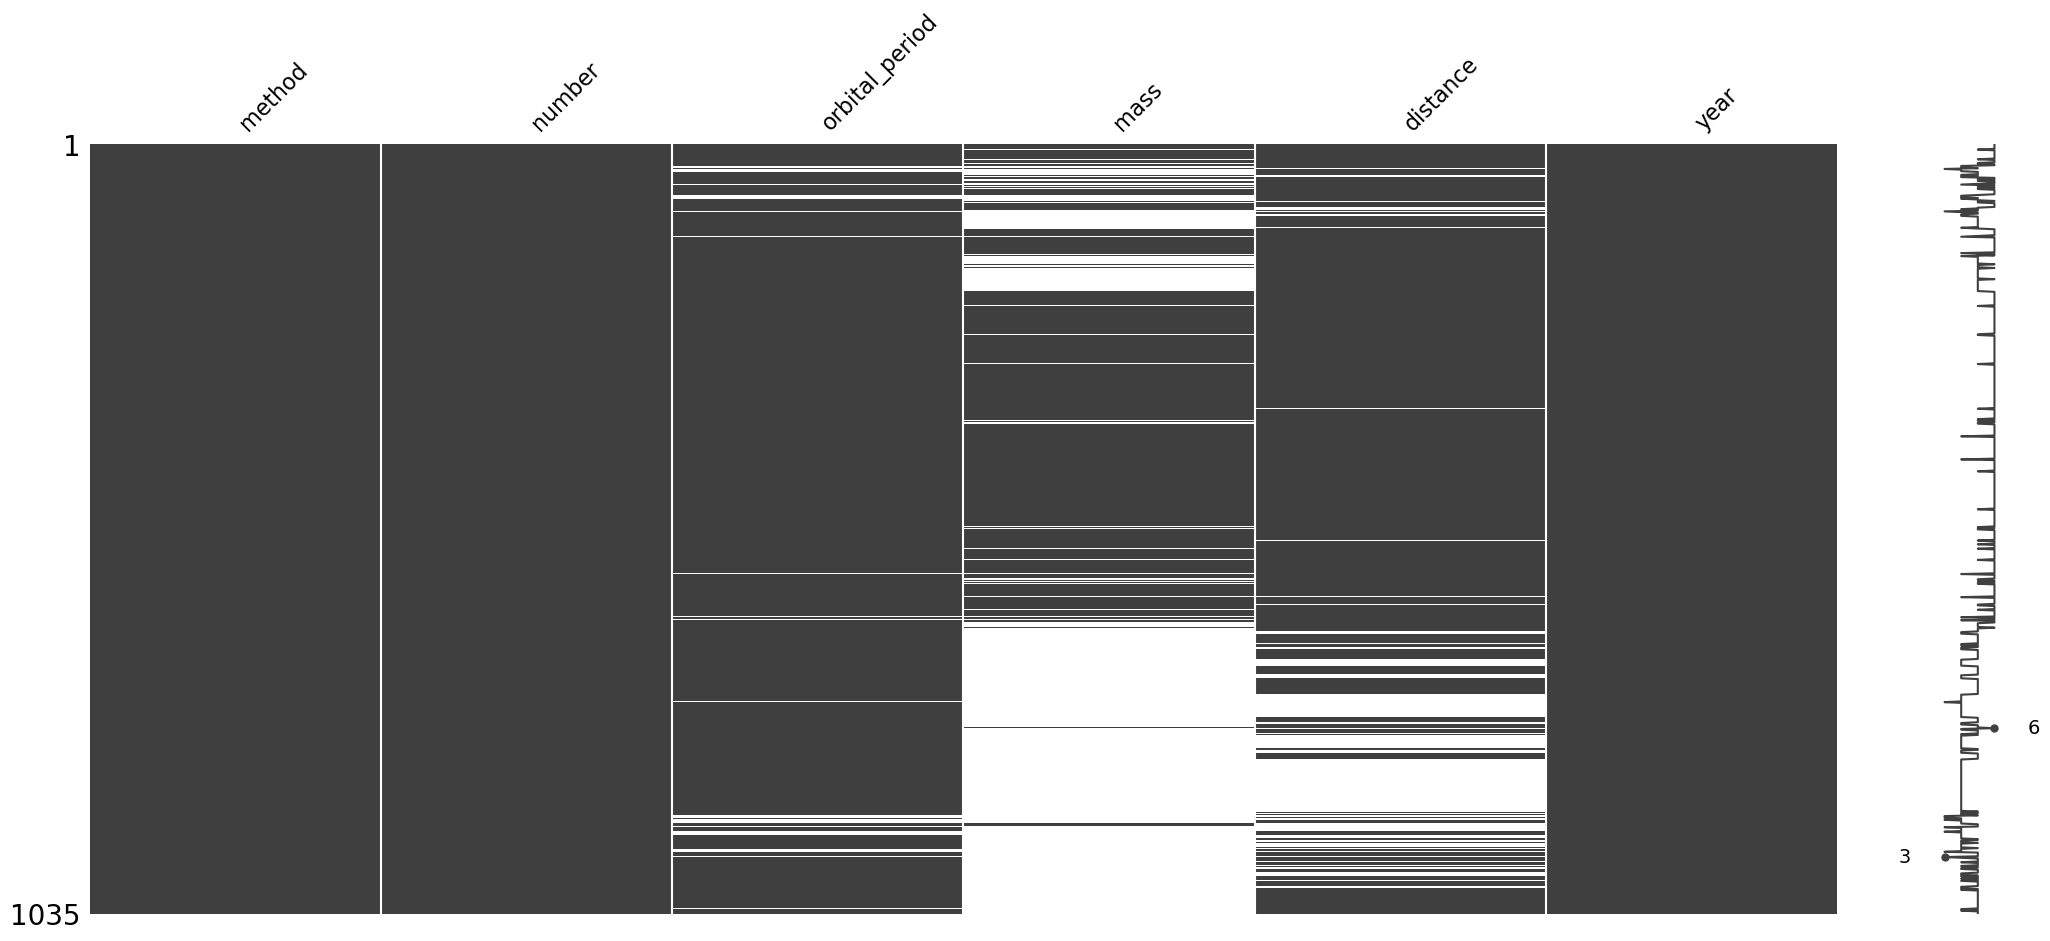

In [16]:
msno.matrix(df);

*Grafiği inceleyelim. orbital_period ile mass değişkenlerine dikkatlice bakalım.En yukarıya baktığımızda Ne zaman orbital_period'da bir NaN değer oluşmuşsa mass değişkeninde de NaN değer oluşmuş.Burada bir bağımlılık var.Yani mass değişkenindeki boşluklar orbital_period değişkenine bağlı olarak gerçekleşmiş.Fakat belli bir yerden sonra mass değişkenleri tamamen NaN değer almış,buna karşılık gelen orbital_period'taki gözlem değerleri halen dolu.Rassantısal olmayan bir kayıp söz konusu. Direkt silme veya atama işlemine geçemeyiz çünkü yapısal bir bozukluk var.*

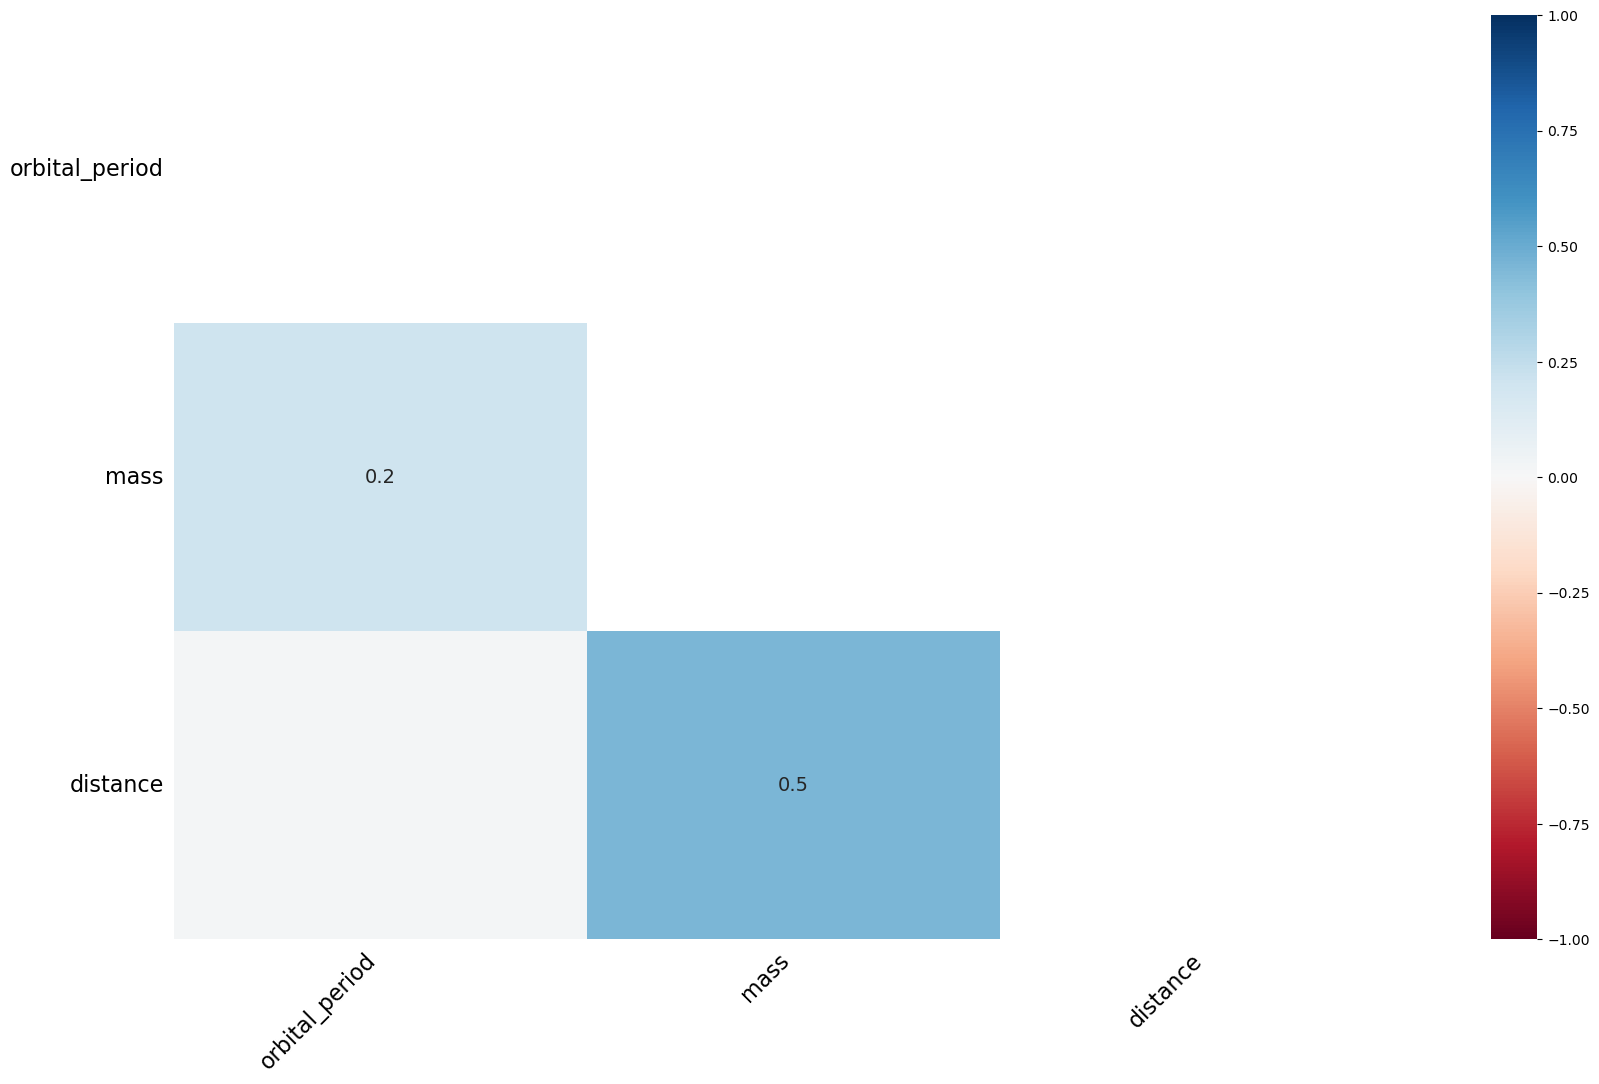

In [17]:
msno.heatmap(df);

*Yukarıdaki heatmap bize **nullity correlation** dediğimiz bir korelasyon ilişkisi hakkında çıkarımlar yapmamızı sağlar. Eğer korelasyon 1 ise bir değişkendeki boşluk, yüksek ihtimalle başka bir değişkendeki boşluktan kaynaklanıyor yani bağımlıdırlar sonucunu çıkarırız. mass ile distance değişkenleri arasındaki bağımlı ilişkiyi matrix'e bakarak çıkaramadık. Burada görüyoruz ki mass'teki NaN değerleri %50 oranında distance'taki NaN değerlerine bağlı olarak gerçekleşmiş. Yani deriz ki: mass değişkeni ile distance değişkeni arasında orta şiddetli bir boşluk korelasyonu vardır.* 